# Data exploration and undrestanding **FGVC-Aircraft** dataset :

In [4]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## Load dataset : (using torchvision)

In [3]:
# transformation pipeline :
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# load dataset
train_dataset = torchvision.datasets.FGVCAircraft(
    root="data/fgvc_aircraft",   # where data will be downloaded/stored
    split="train",
    transform=transform,
    download=True
)

val_dataset = torchvision.datasets.FGVCAircraft(
    root="data/fgvc_aircraft",
    split="val",
    transform=transform,
    download=False
)

test_dataset = torchvision.datasets.FGVCAircraft(
    root="data/fgvc_aircraft",
    split="test",
    transform=transform,
    download=False
)

# data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

100%|██████████| 2.75G/2.75G [03:00<00:00, 15.3MB/s]


In [6]:
print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Validation size: {len(val_dataset)}")

Train size: 3334
Test size: 3333
Validation size: 3333


## Display the first batch of the dataset :

- **batch size** defined : 32

Each image in the FGVC-Aircraft dataset is annotated with three hierarchical labels: **manufacturer**, **family**, and **variant**.
- 30 manifacturer (e.g., Boeing, Airbus)
- 70 family (e.g., Boeing 737, Boeing 707)
- 100 variant (e.g., Boeing 737-800, Boeing 737-200)

In this project, we use the variant as the label because it best shows the visual differences between aircraft and is the most informative for fine-grained classification.

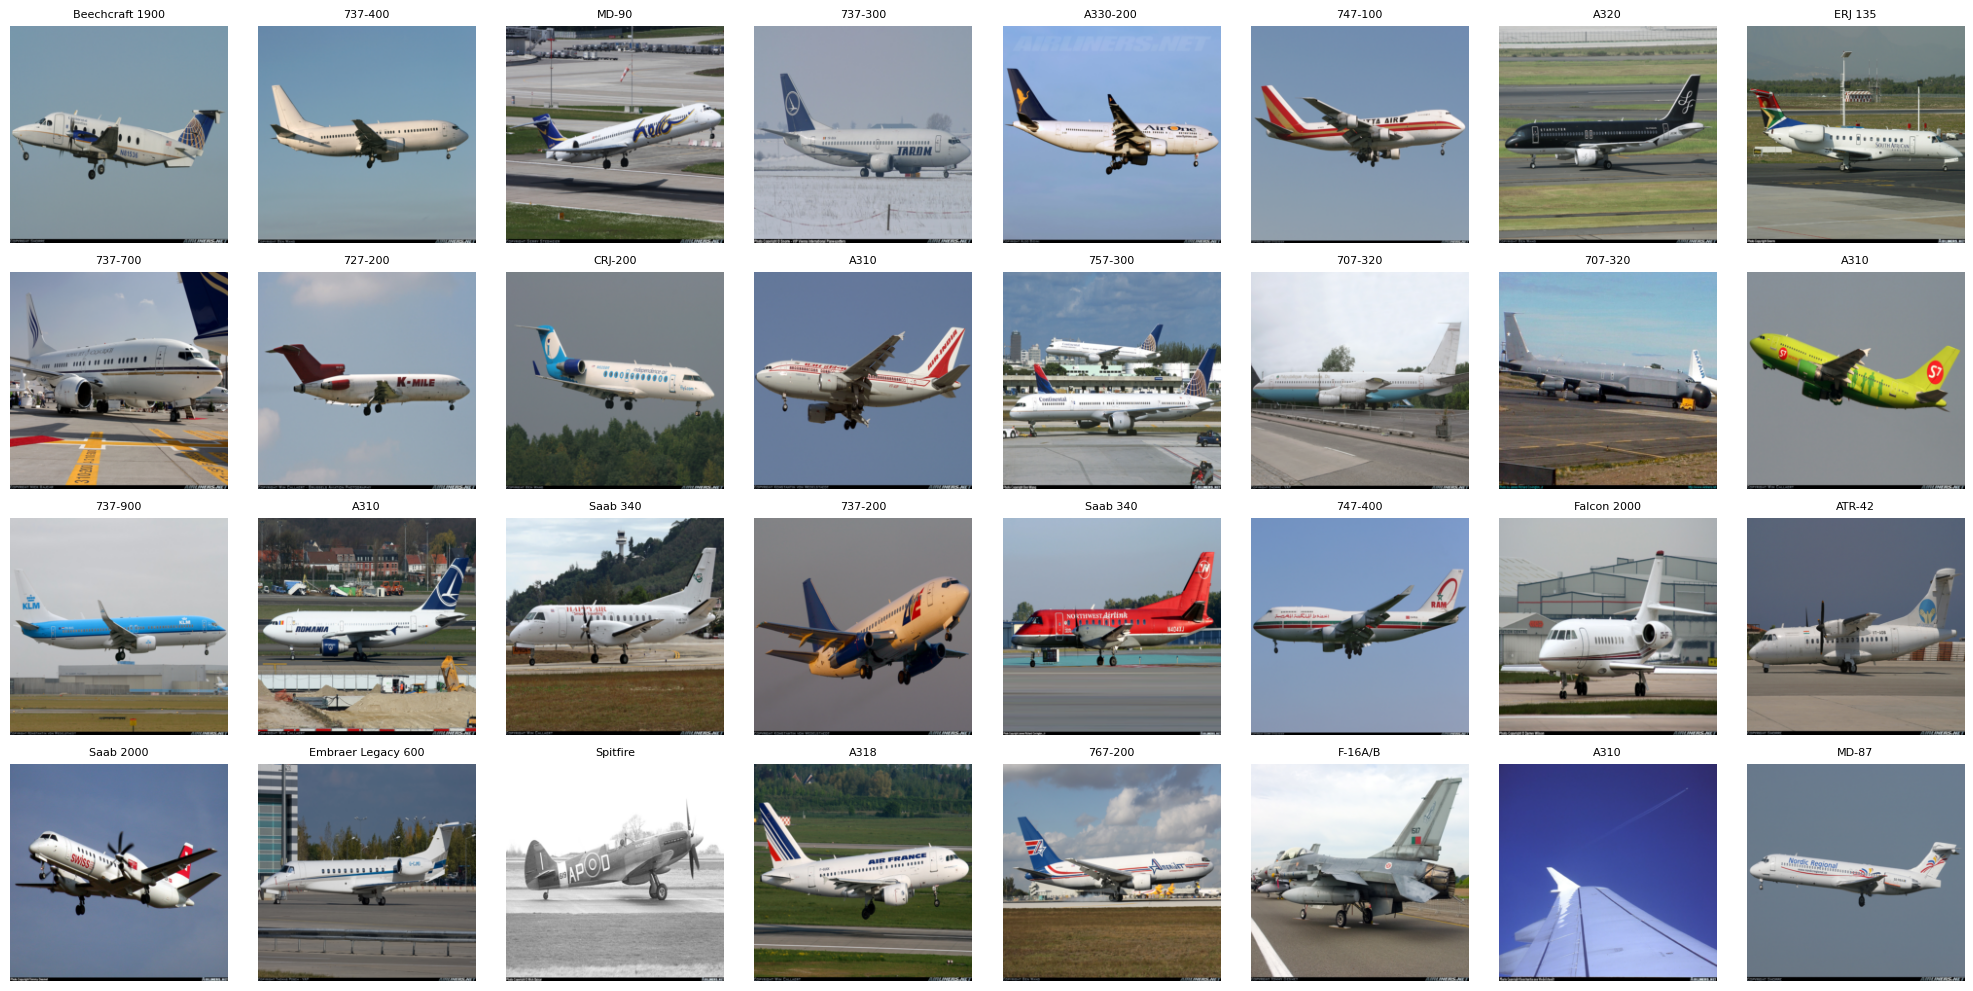

In [5]:
# Get the first batch
images, labels = next(iter(train_loader))

# Unnormalize images (ImageNet normalization)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

images = images.clone().cpu()
images = images * std + mean

# Plot each image with its variant label
batch_size = images.size(0)
cols = 8
rows = (batch_size + cols - 1) // cols  # ceil division

plt.figure(figsize=(20, rows * 2.5))
for i in range(batch_size):
    plt.subplot(rows, cols, i + 1)
    img = images[i].permute(1, 2, 0).numpy()  # C,H,W → H,W,C
    plt.imshow(img)
    plt.title(train_dataset.classes[labels[i].item()], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Display manifacturer, family and variants :

In [8]:
# Load dataset at different annotation levels
train_variant = torchvision.datasets.FGVCAircraft(
    root="data/fgvc_aircraft",
    split="train",
    annotation_level="variant",
    download=False
)

train_family = torchvision.datasets.FGVCAircraft(
    root="data/fgvc_aircraft",
    split="train",
    annotation_level="family",
    download=False
)

train_manufacturer = torchvision.datasets.FGVCAircraft(
    root="data/fgvc_aircraft",
    split="train",
    annotation_level="manufacturer",
    download=False
)

In [9]:
print("Variant classes:", train_variant.classes)
print("Number of variants:", len(train_variant.classes))

print("Family classes:", train_family.classes)
print("Number of families:", len(train_family.classes))

print("Manufacturer classes:", train_manufacturer.classes)
print("Number of manufacturers:", len(train_manufacturer.classes))

Variant classes: ['707-320', '727-200', '737-200', '737-300', '737-400', '737-500', '737-600', '737-700', '737-800', '737-900', '747-100', '747-200', '747-300', '747-400', '757-200', '757-300', '767-200', '767-300', '767-400', '777-200', '777-300', 'A300B4', 'A310', 'A318', 'A319', 'A320', 'A321', 'A330-200', 'A330-300', 'A340-200', 'A340-300', 'A340-500', 'A340-600', 'A380', 'ATR-42', 'ATR-72', 'An-12', 'BAE 146-200', 'BAE 146-300', 'BAE-125', 'Beechcraft 1900', 'Boeing 717', 'C-130', 'C-47', 'CRJ-200', 'CRJ-700', 'CRJ-900', 'Cessna 172', 'Cessna 208', 'Cessna 525', 'Cessna 560', 'Challenger 600', 'DC-10', 'DC-3', 'DC-6', 'DC-8', 'DC-9-30', 'DH-82', 'DHC-1', 'DHC-6', 'DHC-8-100', 'DHC-8-300', 'DR-400', 'Dornier 328', 'E-170', 'E-190', 'E-195', 'EMB-120', 'ERJ 135', 'ERJ 145', 'Embraer Legacy 600', 'Eurofighter Typhoon', 'F-16A/B', 'F/A-18', 'Falcon 2000', 'Falcon 900', 'Fokker 100', 'Fokker 50', 'Fokker 70', 'Global Express', 'Gulfstream IV', 'Gulfstream V', 'Hawk T1', 'Il-76', 'L-101